# Regresión útilizando aprendizaje de máquinas

En aprendizaje de máquinas, la regresión es la tarea de identificar a qué valor continuo una observación nueva pertenece, tomando como base un entrenamiento previo sobre un grupo de observaciones donde sí se conocían sus valores continuos correspondientes.

In [1]:
import numpy as np
import pandas as pd
import sklearn.preprocessing 
import sklearn.ensemble
import sklearn.linear_model
import sklearn.svm
import sklearn.dummy
import matplotlib.pyplot as plt
import seaborn as sns # Paquete de visualización que funciona sobre matplotlib
from sklearn.tree import plot_tree

Para entrenar y probar los modelos de clasificación, utilizaremos un conjunto de datos que contiene valores de propiedades junto con características asociadas a las mismas.

In [2]:
insurance = pd.read_csv("https://raw.githubusercontent.com/fvillena/biocompu/2022/data/insurance.csv")

In [3]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Verificamos con el método pandas.DataFrame.describe() que las variables no tienen el mismo rango, por lo que seria necesario reescalarlas.

In [4]:
insurance.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
insurance.shape # Obtenemos las dimensiones de nuestro conjunto de datos.

(1338, 7)

Para obtener una intuición general de las relaciones que existen entre variables, una práctica habitual es evaluar la correlación que existe entre las variables, sobretodo la correlación que existe entre las características y la etiqueta. Para esto utilizamos indicadores de estadística clásica como es el coeficiente de correlación de Pearson o Spearman.

In [6]:
correlation = insurance[["age", "bmi", "children", "charges"]].corr() # Por defecto este método calcula la correlación de Pearson.
correlation

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


<Axes: >

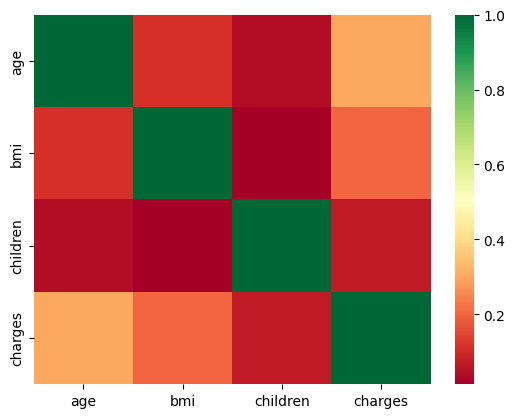

In [7]:
sns.heatmap(
    correlation,
    cmap="RdYlGn" # Utilizamos una paleta de colores divergente para visualizar diferencias en los valores positivos y negativos
) # Utilizamos seaborn para visualizar un mapa de calor de las correlaciones.

## Preprocesamiento

In [8]:
features = insurance.drop("charges", axis=1)

In [9]:
label = insurance.charges

In [10]:
features = pd.get_dummies(features, drop_first=True)

Los algoritmos para entrenar modelos de aprendizaje de máquinas no se comportan bien en su mayoría con diferencias en los rangos de valores de sus características, por lo que es siempre una buena práctica reescalar los valores hacia un rango predeterminado.

In [11]:
scaler = sklearn.preprocessing.MinMaxScaler() # Instanciamos la clase del scaler que realizará una normalización de los datos
features[:] = scaler.fit_transform(features) # Ajustamos el scaler y al mismo tiempo transformamos nuestras características

/tmp/ipykernel_9275/1618403248.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.02173913 0.         0.2173913  ... 0.         0.06521739 0.93478261]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  features[:] = scaler.fit_transform(features) # Ajustamos el scaler y al mismo tiempo transformamos nuestras características
/tmp/ipykernel_9275/1618403248.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.  0.2 0.6 ... 0.  0.  0. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  features[:] = scaler.fit_transform(features) # Ajustamos el scaler y al mismo tiempo transformamos nuestras características
/tmp/ipykernel_9275/1618403248.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0. 1

Verificamos que el rango de todas nuestras características ahora esté entre 0 y 1.

In [12]:
pd.DataFrame(features).describe()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,0.461022,0.395572,0.218984,0.505232,0.204783,0.242900,0.272048,0.242900
std,0.305434,0.164062,0.241099,0.500160,0.403694,0.428995,0.445181,0.428995
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.195652,0.278080,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.456522,0.388485,0.200000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,0.717391,0.504002,0.400000,1.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [13]:
features_train, features_test, label_train, label_test = sklearn.model_selection.train_test_split( 
    features,
    label,
    test_size=0.30, 
    random_state = 11, 
)

In [14]:
lr = sklearn.linear_model.LinearRegression()
lr.fit(features_train, label_train) 

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
lr_predictions = lr.predict(features_test)

In [16]:
dummy = sklearn.dummy.DummyRegressor()
dummy.fit(features_train, label_train)

,strategy,'mean'
,constant,None
,quantile,None


In [17]:
dummy_predictions = dummy.predict(features_test)

## Mean absolute error

El error absoluto medio es el promedio de los errores que cometió el modelor respecto a las etiquetas verdaderas del conjunto de prueba y se define como:

$$
\mathrm{MAE} = \frac{\sum_{i=1}^n\left| y_i - \hat{y_i}\right|}{n}
$$

donde $y_i$ son las etiquetas verdaderas y \hat{y_i} son las etiquetas predichas por el modelo.

In [18]:
def mae(true, predicted):
    error = true-predicted
    absolute_error = np.abs(error)
    return absolute_error.mean()

In [19]:
mae(label_test,lr_predictions)

np.float64(4071.0205797491826)

In [20]:
mae(label_test,dummy_predictions)

np.float64(9022.285193218884)

## Root mean squared error

La raíz del error cuadrádico medio es la raíz promedio de los errores cuadráticos que cometió el modelor respecto a las etiquetas verdaderas del conjunto de prueba. Este error penaliza con mayor importancia los errores más grandes que comerió el modelo y se define como:

$$
\mathrm{RMSE} = \sqrt{\frac{\sum_{i=1}^n\left( y_i - \hat{y_i}\right)^2}{n}}
$$

In [21]:
def rmse(true, predicted):
    error = true-predicted
    squared_error = error**2
    return (squared_error.mean())**0.5

In [22]:
rmse(label_test,lr_predictions)

np.float64(5729.713781282676)

In [23]:
rmse(label_test,dummy_predictions)

np.float64(11850.321704740843)

## $R^2$

El coeficiente de determinación es la proporción de la varianza en la variable dependiente que pudo predecir el modelo y se define como:

Si $\bar{y}$ es el promedio de los datos verdaderos:

$$
\bar{y}=\frac{1}{n}\sum_{i=1}^n y_i ,
$$

la suma de los cuadrados de los errores es

$$
SS_\text{res}=\sum_i (y_i - \hat{y})^2,
$$

la suma de los cuadrados del conjunto de datos

$$
SS_\text{tot}=\sum_i (y_i - \bar{y})^2,
$$

entonces 

$$
R^2 = 1 - {SS_{\rm res}\over SS_{\rm tot}}
$$

In [24]:
def r2(true, predicted):
    residual = true - predicted
    residual_variance = (residual ** 2).mean()
    true_variance = np.var(true) 
    return 1 - (residual_variance / true_variance)

In [25]:
r2(label_test,lr_predictions)

np.float64(0.7660901666687134)

In [26]:
r2(label_test,dummy_predictions)

np.float64(-0.0005594643625606022)

In [27]:
def regression_report(y_true, y_pred):
    """
    Esta función recibe un arreglo de valores reales y predichos para 
    retornar un diccionario con una serie de métricas de regresión
    """
    return {
        'mae': sklearn.metrics.mean_absolute_error(y_true, y_pred),
        'rmse': sklearn.metrics.mean_squared_error(y_true, y_pred) ** 0.5,
        'r2': sklearn.metrics.r2_score(y_true, y_pred)
    }

In [28]:
lr_regression_report = regression_report(label_test, lr_predictions)
lr_regression_report

{'mae': 4071.0205797491826,
 'rmse': 5729.713781282676,
 'r2': 0.7660901666687134}

In [29]:
dummy_regression_report = regression_report(label_test, dummy_predictions)
dummy_regression_report

{'mae': 9022.285193218884,
 'rmse': 11850.321704740843,
 'r2': -0.0005594643625606022}

## Modelamiento

Para evaluar el rendimiento de nuestro modelos sobre el conjunto de prueba debemos utilizar métricas distintas a las que usábamos en clasificación. sklearn nos ofrece una serie de métricas especificas para regresión, las cuales se encuentran todas descritas en la documentación https://scikit-learn.org/stable/modules/model_evaluation.html .

### Support vector machine

In [30]:
svm = sklearn.svm.SVR(kernel="linear", C=10, epsilon=0.1) # Instanciamos una support vector machine con un kernel lineal
svm.fit(features_train, label_train)

,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,10
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [31]:
svm_predictions = svm.predict(features_test)

In [32]:
svm_regression_report = regression_report(label_test, svm_predictions)
svm_regression_report

{'mae': 7513.057583213357,
 'rmse': 11648.60029262567,
 'r2': 0.03321454059643736}

### Random forests

In [33]:
rf = sklearn.ensemble.RandomForestRegressor()
rf.fit(features_train, label_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [34]:
rf_predictions = rf.predict(features_test)

In [35]:
rf_regression_report = regression_report(label_test, rf_predictions)
rf_regression_report

{'mae': 2616.1875788885573, 'rmse': 4605.210095137488, 'r2': 0.848894066049867}

## Resumen

Evaluemos cuál fue el modelo que tuvo el mejor rendimiento en cada una de las métricas.

In [36]:
performances = pd.DataFrame( # Consolidamos todas las métricas en un DatFrame
    data = [
        lr_regression_report,
        svm_regression_report,
        rf_regression_report,
        dummy_regression_report
    ],
    index = [
        "Linear Regression",
        "Support Vector Machine",
        "Random Forest",
        "Regresor Tonto"
    ]
).sort_values( # Ordenamos los valores
    by="rmse"
)
performances

,mae,rmse,r2
Random Forest,2616.187579,4605.210095,0.848894
Linear Regression,4071.020580,5729.713781,0.766090
Support Vector Machine,7513.057583,11648.600293,0.033215
Regresor Tonto,9022.285193,11850.321705,-0.000559


([0, 1, 2, 3],
 [Text(0, 0, 'Random Forest'),
  Text(1, 0, 'Linear Regression'),
  Text(2, 0, 'Support Vector Machine'),
  Text(3, 0, 'Regresor Tonto')])

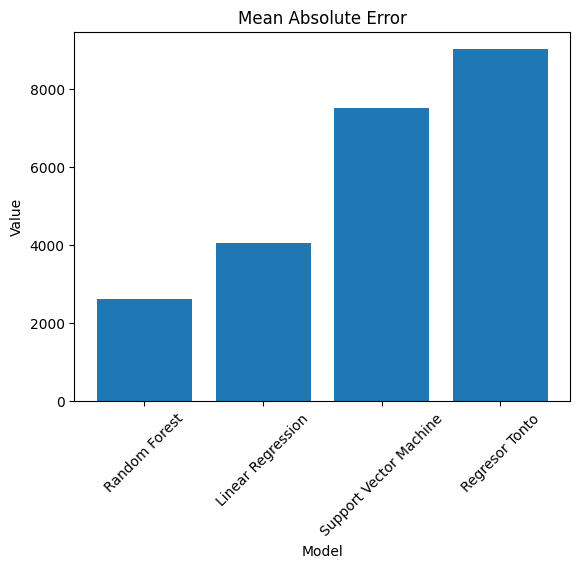

In [37]:
plt.bar( # Visualizamos los resultados como un gráfico de barras
    x=performances.index,
    height=performances.mae,
)
plt.title("Mean Absolute Error")
plt.xlabel("Model")
plt.ylabel("Value")
plt.xticks(rotation=45)

([0, 1, 2, 3],
 [Text(0, 0, 'Random Forest'),
  Text(1, 0, 'Linear Regression'),
  Text(2, 0, 'Support Vector Machine'),
  Text(3, 0, 'Regresor Tonto')])

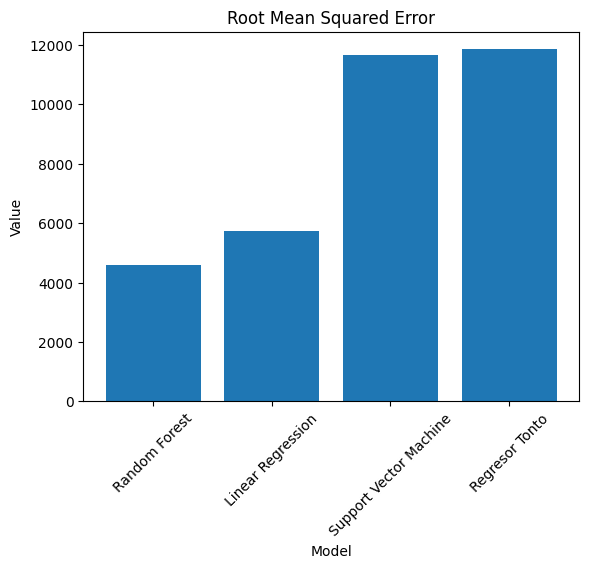

In [38]:
plt.bar(
    x=performances.index,
    height=performances.rmse,
)
plt.title("Root Mean Squared Error")
plt.xlabel("Model")
plt.ylabel("Value")
plt.xticks(rotation=45)

([0, 1, 2, 3],
 [Text(0, 0, 'Random Forest'),
  Text(1, 0, 'Linear Regression'),
  Text(2, 0, 'Support Vector Machine'),
  Text(3, 0, 'Regresor Tonto')])

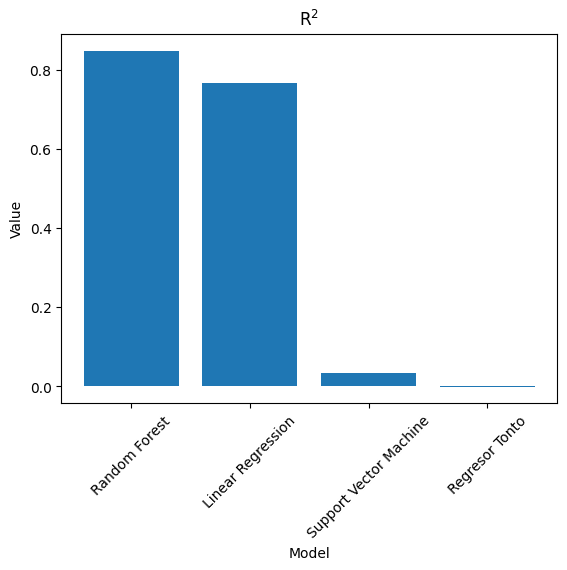

In [39]:
plt.bar(
    x=performances.index,
    height=performances.r2,
)
plt.title("R$^2$")
plt.xlabel("Model")
plt.ylabel("Value")
plt.xticks(rotation=45)

In [40]:
rf_vil = pd.DataFrame(list(zip(insurance.columns[:-1],rf.feature_importances_)),
             columns=["feature","importance"]
            ).set_index("feature")
rf_vil.sort_values("importance",ascending=False)

,importance
feature,
smoker,0.608883
sex,0.212806
age,0.135431
bmi,0.022793
region,0.005726
children,0.005592


In [41]:
rf_tree = rf.estimators_[-3]

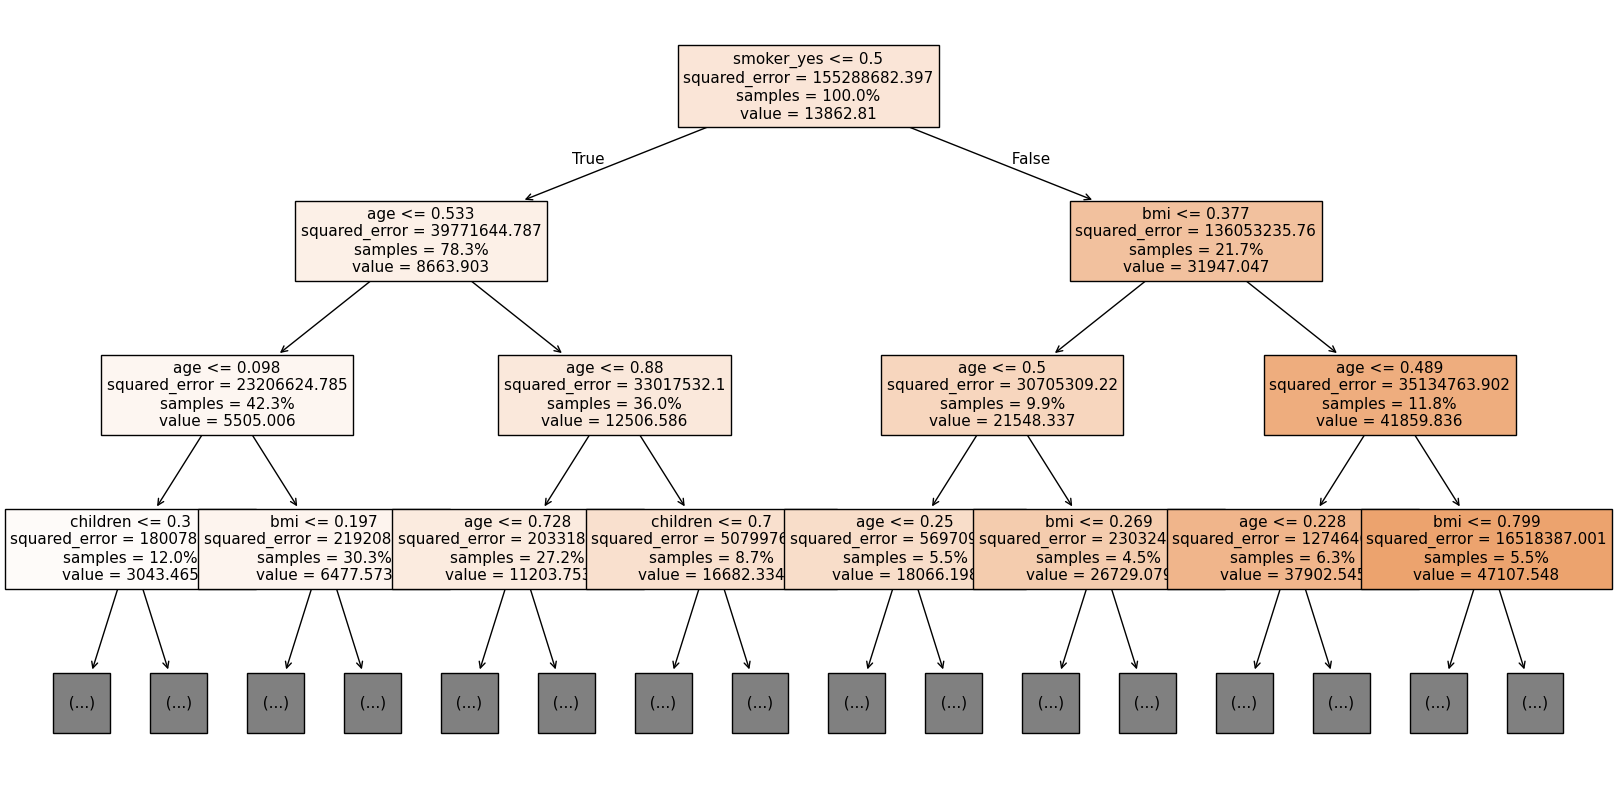

In [42]:
plt.figure(figsize = (20,10))
plot_tree( # Función que nos permite visualizar el árbol de decisión ajustado.
    rf_tree, # Objeto de nuestro árbol de decisión entrenado.
    feature_names = list(features.columns), # Nombres de las variables utilizadas para entrenar.
    class_names = ["healthy","sick"], # Nombre de las clases que estamos prediciendo.
    label = "all", # Etiquetamos todas características de cada nodo.
    proportion = True, # Visualizamos las proporciones de datos en cada nodo de decisión,
    filled=True, # Coloreamos los nodos
    fontsize=11, # Establecemos el tamaño de la letra del texto dentro de cada nodo.,
    max_depth=3 # Profundidad máxima del árbol
)
plt.show()